# Анализ данных по сотрудникам

## Цель и задачи  

**Цель:** Проанализировать данные, выявить закономерности, сделать выводы и предложить рекомендации для улучшения показателей.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа поступили данные по 25 сотрудникам агентства недвижимости за последний месяц. 
### Описание данных

1.	Количество звонков (исходящих).
2.	Количество SMS (отправленных клиентам).
3.	Количество встреч с клиентами.
4.	Количество выставленных листингов (объектов недвижимости).
5.	Количество подписанных договоров с клиентами.
6.	Количество эксклюзивных договоров.
7.	Количество полученных авансов.
8.	Количество завершенных сделок.
9.	Среднее время обработки звонка (в минутах).
10.	Среднее время подготовки листинга (в часах).
11.	Среднее время между встречей и подписанием договора (в днях).
12.	Средний размер аванса (в рублях).
13.	Средний размер комиссии за сделку (в рублях).
14.	Процент завершенных сделок от общего числа договоров.
15.	Процент эксклюзивных договоров от общего числа договоров.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Исследовательский анализ данных.
3. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасета. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним переменную `staff` .

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import phik
from phik import phik_matrix

import warnings
warnings.filterwarnings('ignore')

In [66]:
# Выгружаем данные в переменную staff:
staff = pd.read_excel('Данные для тестового задания (1).xlsx')

In [67]:
# Выводим первые строки датафрейма на экран
staff.head()

,Сотрудник,Звонки,SMS,Встречи,Листинги,Договора,Эксклюзивы,Авансы,Сделки,Среднее время обработки звонка (мин),Среднее время подготовки листинга (часы),Среднее время между встречей и подписанием договора (дни),Средний размер аванса (руб),Средний размер комиссии за сделку (руб),Процент завершенных сделок от общего числа договоров,Процент эксклюзивных договоров от общего числа договоров
0,Иванов А.А.,120,50,15,10,8,3,5,4,5.2,3.5,7,50000,120000,0.500000,0.375000
1,Петрова В.С.,90,30,10,7,5,2,3,3,4.8,4.0,5,45000,110000,0.600000,0.400000
2,Сидоров Д.И.,150,60,20,12,10,4,6,5,6.0,3.0,6,60000,130000,0.500000,0.400000
3,Кузнецова Е.П.,80,25,8,6,4,1,2,2,5.5,3.8,8,55000,125000,0.500000,0.250000
4,Васильев М.К.,200,70,25,15,12,5,8,7,4.5,4.5,4,40000,100000,0.583333,0.416667


In [68]:
# Выводим информацию о датафрейме
staff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 16 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Сотрудник                                                  25 non-null     object 
 1   Звонки                                                     25 non-null     int64  
 2   SMS                                                        25 non-null     int64  
 3   Встречи                                                    25 non-null     int64  
 4   Листинги                                                   25 non-null     int64  
 5   Договора                                                   25 non-null     int64  
 6   Эксклюзивы                                                 25 non-null     int64  
 7   Авансы                                                     25 non-null     int64  
 8   Сделки      

Датасет содержит 16 столбцов и 25 строк, в которых представлена информация о сотрудниках.

После первичного анализа данных можно сделать следующие выводы:
- Данные представлены в трех типах данных `int64`, `float64` и `object`.
- Пропусков в данных нет
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


## 2. Исследовательский анализ данных
Далее произведем анализ данных:

- Проведем описательный анализ данных
- Построем графики и диаграммы для визуализации ключевых показателей
- Выявим топ-5 сотрудников по количеству завершенных сделок и по размеру комиссии.
- Определии сотрудников с самыми низкими показателями по количеству встреч и подписанных договоров.


In [69]:
# Изучаем статистические показатели столбца balance
print('Статистические показатели:')
staff.describe()

Статистические показатели:


,Звонки,SMS,Встречи,Листинги,Договора,Эксклюзивы,Авансы,Сделки,Среднее время обработки звонка (мин),Среднее время подготовки листинга (часы),Среднее время между встречей и подписанием договора (дни),Средний размер аванса (руб),Средний размер комиссии за сделку (руб),Процент завершенных сделок от общего числа договоров,Процент эксклюзивных договоров от общего числа договоров
count,25.000000,25.000000,25.00000,25.00000,25.000000,25.000000,25.00,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,121.040000,45.680000,14.60000,9.60000,7.360000,3.000000,4.44,4.000000,5.288000,3.724000,6.440000,51600.000000,119680.000000,0.538089,0.385911
std,38.692678,16.100518,6.35741,3.62859,3.212994,1.554563,2.20,1.802776,0.510163,0.397157,1.583246,5825.590099,11721.490235,0.067214,0.106552
min,65.000000,18.000000,4.00000,3.00000,2.000000,0.000000,1.00,1.000000,4.500000,3.000000,4.000000,40000.000000,100000.000000,0.333333,0.000000
25%,90.000000,32.000000,9.00000,7.00000,5.000000,2.000000,3.00,3.000000,4.900000,3.400000,5.000000,47500.000000,110000.000000,0.500000,0.375000
50%,115.000000,48.000000,15.00000,10.00000,8.000000,3.000000,5.00,4.000000,5.200000,3.700000,6.000000,52000.000000,120000.000000,0.545455,0.400000
75%,145.000000,59.000000,20.00000,13.00000,10.000000,4.000000,6.00,5.000000,5.700000,4.000000,8.000000,56000.000000,129000.000000,0.583333,0.444444
max,200.000000,70.000000,25.00000,15.00000,12.000000,5.000000,8.00,7.000000,6.200000,4.500000,9.000000,60500.000000,140000.000000,0.666667,0.500000


Можно предположить, что данные по сотрудникам имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако стандартное отклонение достаточно большое, что говорит о значительной разнице в активности между сотрудниками.
Небольшие выводы по данным: 
- Звонки: 75% сотрудников делают менее 145 звонков. Это значит, что есть сотрудники, которые делают значительно больше звонков, чем большинство (выбросы в большую сторону).
- Договоры: 50% сотрудников подписывают 8 или менее договоров.
- Сделки: 50% сотрудников закрывают 4 или менее сделок.
- Процент завершенных сделок: У 75% сотрудников процент завершенных сделок составляет около 58% или меньше. Это говорит о том, что есть сотрудники с более высокой конверсией (выше 58%), которые могут быть примером для остальных.
- Эксклюзивы: 25% сотрудников заключают только 2 эксклюзивных договора или меньше.
- Длительность цикла сделки: 75% сотрудников тратят на период от встречи до подписания договора 8 дней или меньше.

Далее рассмотрим топ 5 сотрудников

In [95]:
#Топ-5 сотрудников по количеству завершенных сделок
sorted_staff= staff.sort_values(by = 'Сделки', ascending=False)
sorted_staff[['Сотрудник','Договора','Сделки']].head()

,Сотрудник,Договора,Сделки
4,Васильев М.К.,12,7
16,Дмитриев В.Р.,12,7
13,Борисова А.К.,11,6
20,Тарасов И.Н.,11,6
8,Павлов А.Н.,11,6


In [71]:
#Топ-5 сотрудников по размеру комиссии
sorted_staff= staff.sort_values(by = 'Средний размер комиссии за сделку (руб)', ascending=False)
sorted_staff[['Сотрудник','Средний размер комиссии за сделку (руб)']].head()

,Сотрудник,Средний размер комиссии за сделку (руб)
21,Захарова Е.А.,140000
15,Федорова Н.И.,138000
6,Морозов И.В.,135000
18,Киселев А.Д.,134000
12,Григорьев П.С.,132000


In [94]:
#Топ-5 сотрудников по проценту завершенных сделок от общего числа договоров 
sorted_staff= staff.sort_values(by = 'Процент завершенных сделок от общего числа договоров ', ascending=False)
sorted_staff[['Сотрудник','Договора','Сделки','Процент завершенных сделок от общего числа договоров ']].head()

,Сотрудник,Договора,Сделки,Процент завершенных сделок от общего числа договоров
14,Макаров Д.О.,6,4,0.666667
5,Николаева О.Л.,6,4,0.666667
1,Петрова В.С.,5,3,0.600000
21,Захарова Е.А.,5,3,0.600000
9,Козлова Л.М.,5,3,0.600000


Лидирующие позиции по количеству завершенных сделок занимают Васильев и Дмитриев, а по размеру комисии Захарова и Федорова. Несмотря на то, что Васильев и Дмитриев закрыли больше всех сделок в топ 5 по комисии они не вошли. Можно сделать вывод, что комисии зависит от суммы сделки, а не от количетсва заключенных договоров.

Построим гистограммы распределения по количеству звонков, сделок и авансов а так же рассмотрим количество сделок по кахжому сотруднику

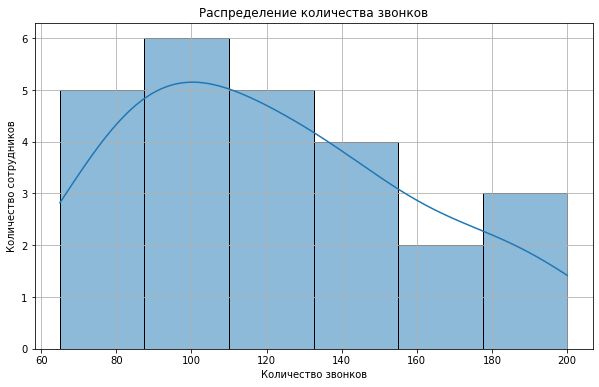

In [72]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму 
sns.histplot(staff['Звонки'], kde=True,)

# Настраиваем оформление графика
plt.title('Распределение количества звонков')
plt.xlabel('Количество звонков')
plt.ylabel('Количество сотрудников')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

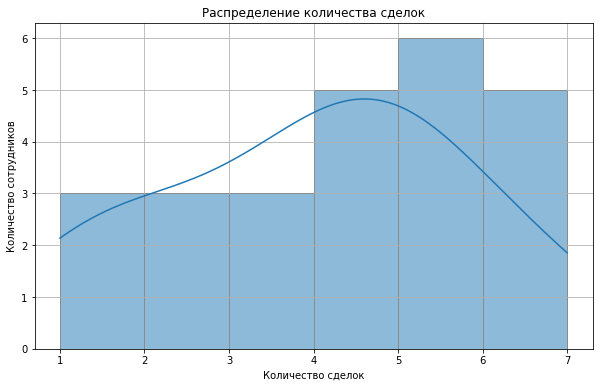

In [73]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму 
sns.histplot(staff['Сделки'], kde=True,)

# Настраиваем оформление графика
plt.title('Распределение количества сделок')
plt.xlabel('Количество сделок')
plt.ylabel('Количество сотрудников')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

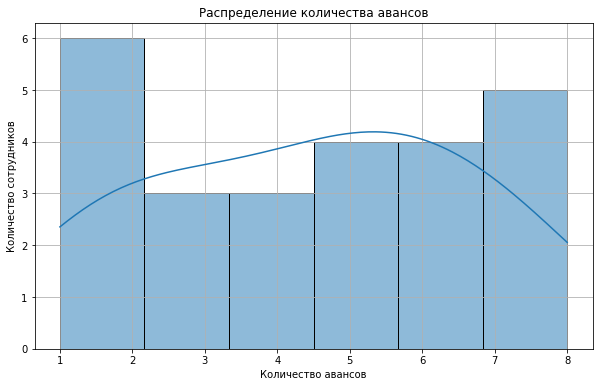

In [74]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму
sns.histplot(staff['Авансы'], kde=True,)

# Настраиваем оформление графика
plt.title('Распределение количества авансов')
plt.xlabel('Количество авансов')
plt.ylabel('Количество сотрудников')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

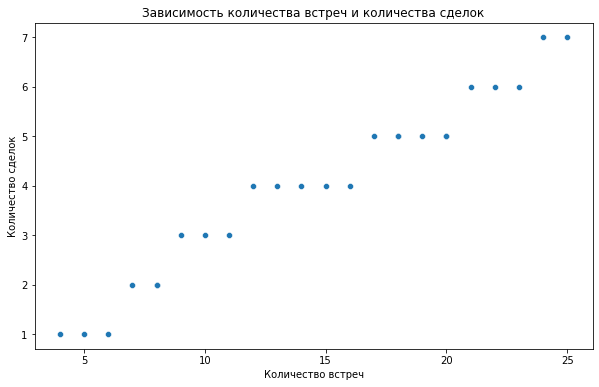

In [75]:
# d) Диаграмма рассеяния: Зависимость количества встреч и количества сделок
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Встречи', y='Сделки', data=staff)
plt.title('Зависимость количества встреч и количества сделок')
plt.xlabel('Количество встреч')
plt.ylabel('Количество сделок')
plt.show()

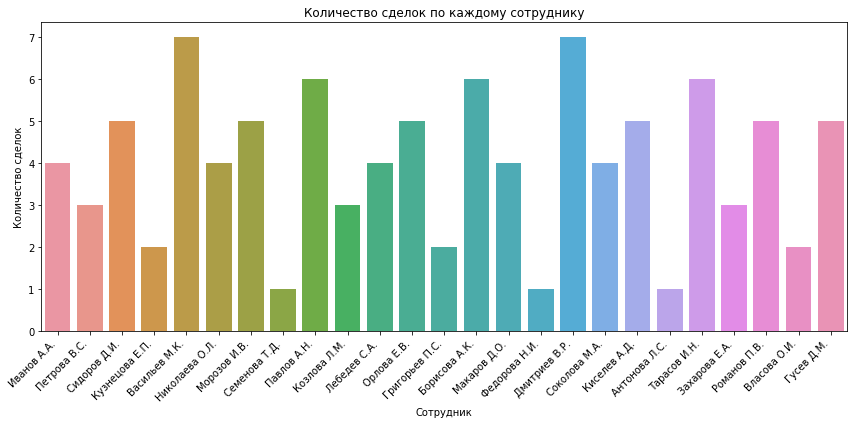

In [76]:
# Создаём контейнер Столбчатая диаграмма: Количество сделок по каждому сотруднику
plt.figure(figsize=(12, 6))
sns.barplot(x='Сотрудник', y='Сделки', data=staff)
plt.title('Количество сделок по каждому сотруднику')
plt.xlabel('Сотрудник')
plt.ylabel('Количество сделок')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()

По графику распределения по количеству звонков видно правое ассиметрическое распределение, это означает, что среднее значение смещено вправо. По распределению сделок и аванса наблюдается симметрическое распределение.

По диаграмме рассеивания наблюдается восходящая линия, это говорит о том, что больше встреч обычно приводит к большему количеству сделок.



Рассмотрим антитоп сотрудников

In [77]:
#Выявите анти-топ-5 сотрудников по количеству встреч 
sort_staff= staff.sort_values(by = 'Встречи', ascending=True)
sort_staff[['Сотрудник','Встречи']].head()

,Сотрудник,Встречи
19,Антонова Л.С.,4
15,Федорова Н.И.,5
7,Семенова Т.Д.,6
12,Григорьев П.С.,7
3,Кузнецова Е.П.,8


In [78]:
#Выявите анти-топ-5 сотрудников по количеству подписанных договоров
sort_staff= staff.sort_values(by = 'Договора', ascending=True)
sort_staff[['Сотрудник','Договора']].head()

,Сотрудник,Договора
19,Антонова Л.С.,2
15,Федорова Н.И.,2
7,Семенова Т.Д.,3
12,Григорьев П.С.,4
3,Кузнецова Е.П.,4


Лидерами антитопа по количеству встреч и подписанных договоров являются Антонова и Федорова. ранее мы выявили корреляционную зависимость между количеством встреч и количеством договоров в связи с этим данные сотрудники входят в два антитова.
При расчете топ-5 сотрудников по размеру комиссии за сделку Федорова занимала лидирующиее позиции. Возможно она проводила сложные сделки, поэтому по количеству попала в антитоп

Перейдем к дальнейшему анализу и выявим закономерности:
- Найдитем корреляцию между звонками, сделками, договорами и встречами.
- Определим, есть ли связь между количеством SMS и количеством подписанных договоров.
- Проверем, влияет ли среднее время подготовки листинга на количество завершенных сделок.
- Проанализируйтем, как размер аванса влияет на вероятность завершения сделки.


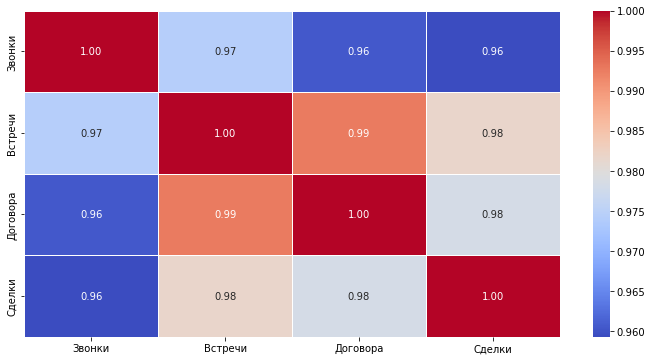

In [79]:
#Построим матрицу корреляции и определим влияние звонков, встреч, договоров и сделок
plt.figure(figsize=(12, 6))
corr_matrix= staff[['Звонки','Встречи', 'Договора', 'Сделки']].corr()
sns.heatmap(corr_matrix, 
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5# Форматируем линию между ячейками карты)
           )
plt.show()

Исходя из матрицы корреляции видно, что значение показателя находится в пределах от 0,96 до 0,99. Это означает, что связь между показателями ярко выражена и увеличение любого из показателей сопровождается увеличением другого

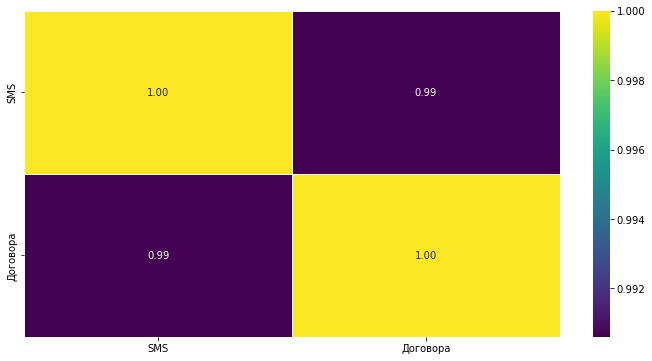

In [80]:
#Построим матрицу корреляции и определим влияние количестива SMS и количесва подписания договоров
plt.figure(figsize=(12, 6))
corr_matrix= staff[['SMS', 'Договора']].corr()
sns.heatmap(corr_matrix, 
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='viridis', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5# Форматируем линию между ячейками карты)
           )
plt.show()

Исходя из матрицы корреляции также видно, что значение показателя равно 0,99. Это означает, что связь между показателями ярко выражена и увеличение любого из показателей сопровождается увеличением другого

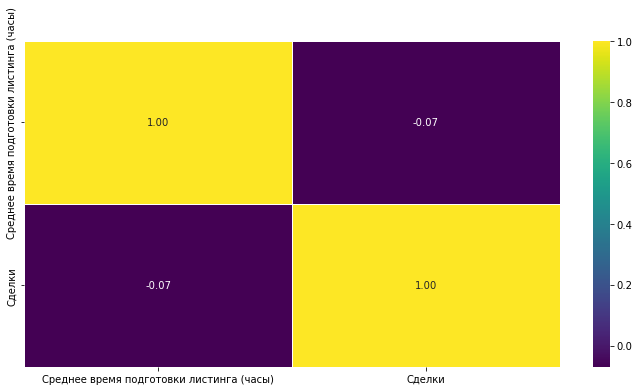

In [81]:
#Построим матрицу корреляции и определим влияние среднего времени подготовки листинга на количество завершенных сделок.
plt.figure(figsize=(12, 6))
corr_matrix= staff[['Среднее время подготовки листинга (часы)', 'Сделки']].corr()
sns.heatmap(corr_matrix, 
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='viridis', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5# Форматируем линию между ячейками карты)
           )
plt.show()

Значение показателя отрицательное может говорить о том, что быстро подготовленные листинги оказываются более эффективными.

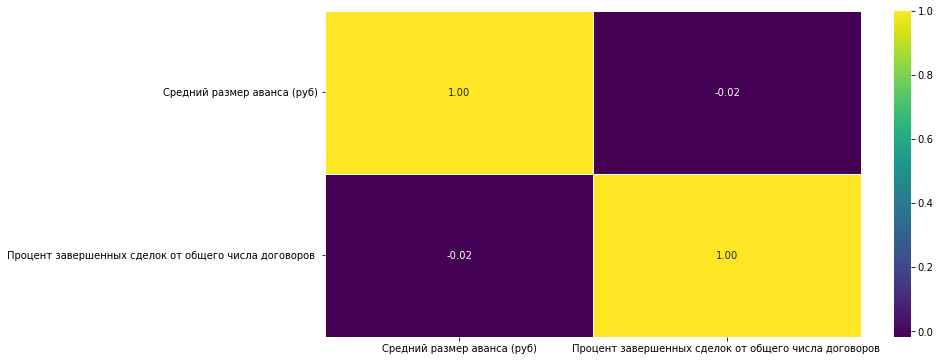

In [86]:
#Построим матрицу корреляции и определим влияние размер аванса на вероятность завершения сделки.
plt.figure(figsize=(12, 6))
corr_matrix= staff[['Средний размер аванса (руб)', 'Процент завершенных сделок от общего числа договоров ']].corr()
sns.heatmap(corr_matrix, 
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='viridis', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5# Форматируем линию между ячейками карты)
           )
plt.show()

 Коэффициент корреляции -0.02 говорит о том, что между средним размером аванса и процентом завершенных сделок нет линейной зависимости. Другими словами, изменение размера аванса практически не связано с изменением процента завершенных сделок, по крайней мере, в линейном смысле. Нельзя сказать, что увеличение аванса приводит к увеличению завершенных сделок, или наоборот.

In [90]:
#Построим корреляциию зависимости завершенных сделок от разных параметров 
correlations = staff.corr()['Процент завершенных сделок от общего числа договоров '].sort_values(ascending=False)
print(correlations)

Процент завершенных сделок от общего числа договоров         1.000000
Процент эксклюзивных договоров от общего числа договоров     0.436669
Сделки                                                       0.372694
Эксклюзивы                                                   0.299278
Авансы                                                       0.272728
SMS                                                          0.247581
Встречи                                                      0.223472
Звонки                                                       0.215875
Договора                                                     0.191306
Листинги                                                     0.182122
Среднее время между встречей и подписанием договора (дни)    0.114296
Средний размер комиссии за сделку (руб)                      0.019656
Среднее время обработки звонка (мин)                         0.002181
Средний размер аванса (руб)                                 -0.018194
Среднее время подгот

Положительные корреляции:
    
- Процент эксклюзивных договоров (0.43): Наиболее значимый положительный фактор. Чем больше доля эксклюзивных договоров, тем выше процент завершенных сделок.
- Встречи (0.22): Количество встреч также положительно влияет на результат. Больше встреч - больше вероятность успешной сделки.
- Остальные положительные корреляции (Звонки, Сделки, Эксклюзивы, Листинги, Договора, SMS) имеют положительный коэффициент, что говорит о том, что они, вероятно, связаны между собой и, возможно, с количеством встреч.
- Среднее время между встречей и подписанием договора (0.11): Чем меньше времени проходит между встречей и подписанием договора, тем выше процент завершенных сделок. Это логично, так как затягивание процесса может привести к потере клиента.
- Среднее время обработки звонка (0.002): Чем меньше времени тратится на обработку одного звонка, тем выше процент завершенных сделок. Возможно, это связано с тем, что сотрудники, умеющие быстро обрабатывать звонки, более эффективно выявляют заинтересованных клиентов.
Отрицательные корреляции:
- Среднее время подготовки листинга (часы) (-0.16): Менее значимая, но все же отрицательная корреляция.

## 3. Итоговые выводы

Из проведенного анализа можно сделать следующиеп выводы:

- Увеличение доли эксклюзивных договоров: Необходимо уделять больше внимания заключению эксклюзивных договоров с клиентами, так как это напрямую связано с увеличением процента завершенных сделок.
- Увеличение количества встреч: Важно стремиться к увеличению количества встреч с потенциальными клиентами.
- Сокращение времени между встречей и подписанием договора: Необходимо ускорять процесс заключения сделки после встречи.
- Сокращение среднего времени обработки звонка: Важно повышать эффективность работы с входящими звонками.

Наилучшие показатели демонстрируют следующие сотрудники:
- Васильев М.К. и Дмитриев В.Р имеют самые высокие показатели среди количества завершенных сделок. При этом сотрудники Захарова Е.А. и Федорова Н.И. имееют самые средние размеры комиссий. Макаров Д.О. и Николаева О.Л. показывают лучшие результатыв в проценте завершенных сделок от общего числа договоров. 

- Сотрудники Антонова Л.С., Федорова Н.И. и Семенова Т.Д. входят в антитов по количеству всреч и подписания договоров. Возможно данным сотрудникам требуется дополнительное обучение по техникам продаж, привлечению клиентов и заключению эксклюзивных договоров.

Мы видим, что у многих сотрудников высокое “Среднее время подготовки листинга”. Можно предположить, что процесс подготовки листингов неэффективен. Нужно изучить, как это делают самые быстрые сотрудники, и разработать шаблоны или автоматизировать часть процесса, чтобы сократить время подготовки листинга для всех.

Исходя из проведенного анализа можно предложить следующие рекомендации:
- Улучшение квалификации лидов: Внедрить систему скоринга лидов (оценка потенциальных клиентов по заданным критериям). Это поможет определить, с какими клиентами стоит встречаться в первую очередь. Проводить более тщательную квалификацию лидов по телефону или онлайн (задавать вопросы о потребностях, бюджете, сроках).
- Оптимизация процесса назначения встреч: Использовать инструменты онлайн-календарей (например, Calendly), чтобы клиенты могли самостоятельно выбирать удобное время для встречи. Предлагать клиентам несколько вариантов времени встречи, чтобы увеличить вероятность согласования.
- Повышение эффективности проведения встреч: Проводить тренинги по техникам продаж и ведения переговоров.Предоставлять сотрудникам шаблоны презентаций и коммерческих предложений.

Рекомендации по улучшению показателей сотрудников с низкой эффективностью:

- Индивидуальный план развития: Разработать для каждого сотрудника с низкой эффективностью индивидуальный план развития, основанный на его слабых сторонах (например, недостаток знаний о продукте, неумение работать с возражениями, низкая активность).
- Регулярная обратная связь: Предоставлять сотрудникам регулярную обратную связь об их работе, отмечать успехи и указывать на области, требующие улучшения.
- Дополнительное обучение.
- Прозрачная система мотивации: Разработать прозрачную и понятную систему мотивации, которая будет стимулировать сотрудников к достижению высоких результатов.
- Признание достижений: Отмечать и поощрять достижения сотрудников, даже небольшие.

Способы сокращения времени между встречей и подписанием договора:

- Персонализация предложений:Собирать максимально полную информацию о потребностях и проблемах клиента на этапе квалификации лида и во время встречи.Готовить персонализированные коммерческие предложения, демонстрирующие, как предлагаемое решение отвечает конкретным потребностям клиента.
- Упрощение процесса заключения договора:Использовать электронный документооборот.Предоставлять клиентам готовые шаблоны договоров, заполненные основной информацией.Оказывать клиентам помощь в оформлении документов.
- Быстрая обратная связь:Оперативно отвечать на все вопросы клиентов.Предоставлять клиентам возможность связаться с сотрудником в любое время удобным для них способом (по телефону, электронной почте, через мессенджеры).
